In [ ]:
import pandas as pd
import re
import torch

#libraries for data explore
import seaborn as sns
import matplotlib.pyplot as plt

#libraries for model training and evolution
from sklearn.model_selection import train_test_split
from transformers import BertTokenizer,BertForSequenceClassification
from transformers import Trainer, TrainingArguments
from transformers import DataCollatorWithPadding
from datasets import Dataset
from sklearn.metrics import accuracy_score, precision_recall_fscore_support


In [ ]:
#example: load a csv dataset
df=pd.read_csv("/content/phishing_legit_dataset_KD_10000.csv")

df.shape

(10000, 5)

In [ ]:
print(df.columns)

Index(['text', 'label', 'phishing_type', 'severity', 'confidence'], dtype='object')


In [ ]:
df=df.drop(["phishing_type","severity","confidence"],axis=1)

In [ ]:
print(df.columns)

Index(['text', 'label'], dtype='object')


In [ ]:
df.rename(columns={'text':'text_combined'},inplace=True)

In [ ]:
print(df.columns)

Index(['text_combined', 'label'], dtype='object')


In [ ]:
#randomly sample 15000 rows from the full dataset
df=df.sample(n=1500, random_state=42).reset_index(drop=True)
print(df.head())

                                       text_combined  label
0  Dear customer, you have a new notification. Pl...      1
1  Subject: Documentation review\n\nThanks for at...      0
2  Dear customer, this is an 48 hours notice rega...      1
3  Subject: Conference registration\n\nAttaching ...      0
4  Hi there, this is an expires soon notice regar...      1


In [ ]:
#remove nulls
df.dropna(inplace=True)
df['label']=df['label'].astype(int)

#loxwercasing only
def clean_text(text_combined):
  return text_combined.lower()

df['text_combined']=df['text_combined'].apply(clean_text)

In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   text_combined  1500 non-null   object
 1   label          1500 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 23.6+ KB
None


In [ ]:
df.shape

(1500, 2)

In [ ]:
df.head()

,text_combined,label
0,"dear customer, you have a new notification. pl...",1
1,subject: documentation review\n\nthanks for at...,0
2,"dear customer, this is an 48 hours notice rega...",1
3,subject: conference registration\n\nattaching ...,0
4,"hi there, this is an expires soon notice regar...",1


In [ ]:
df.tail()

,text_combined,label
1495,"subject: team lunch planning\n\nhello, confirm...",0
1496,subject: workshop recap\n\nplease find the min...,0
1497,"notice, congratulations! you are the winner of...",1
1498,"attention, your account requires verification....",1
1499,subject: training session notes\n\nsharing the...,0


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


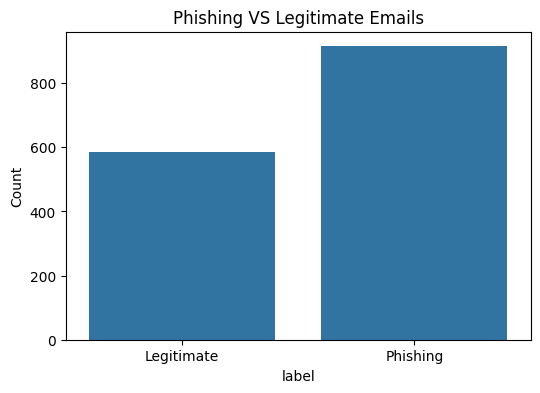

In [ ]:
#exploring the dataset
#plot class distribution
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='label') #counts the number of occurances of each unique value in a column
plt.title('Phishing VS Legitimate Emails')
plt.xticks([0,1],['Legitimate','Phishing'])
plt.ylabel('Count')
plt.show()

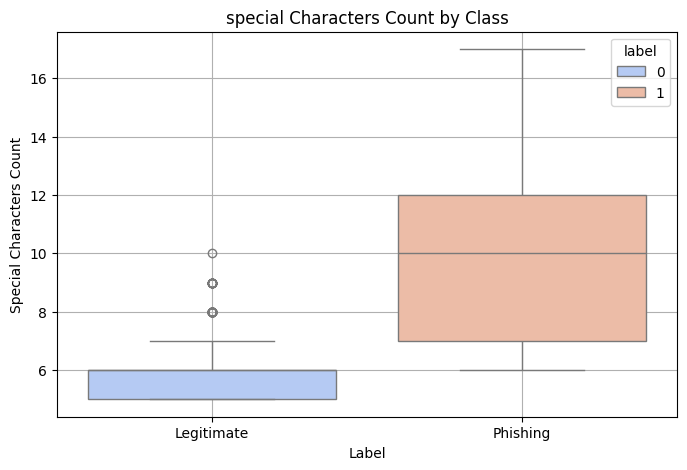

In [ ]:
df['special_chars']=df['text_combined'].apply(lambda x:sum(not c.isalnum() and not c.isspace() for c in x))

plt.figure(figsize=(8,5))
sns.boxplot(x='label', y='special_chars' , data=df ,hue='label', palette='coolwarm', dodge=False)

plt.xticks([0,1], ['Legitimate' , 'Phishing'])
plt.title('special Characters Count by Class')
plt.xlabel('Label')
plt.ylabel('Special Characters Count')
plt.grid(True)
plt.show()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


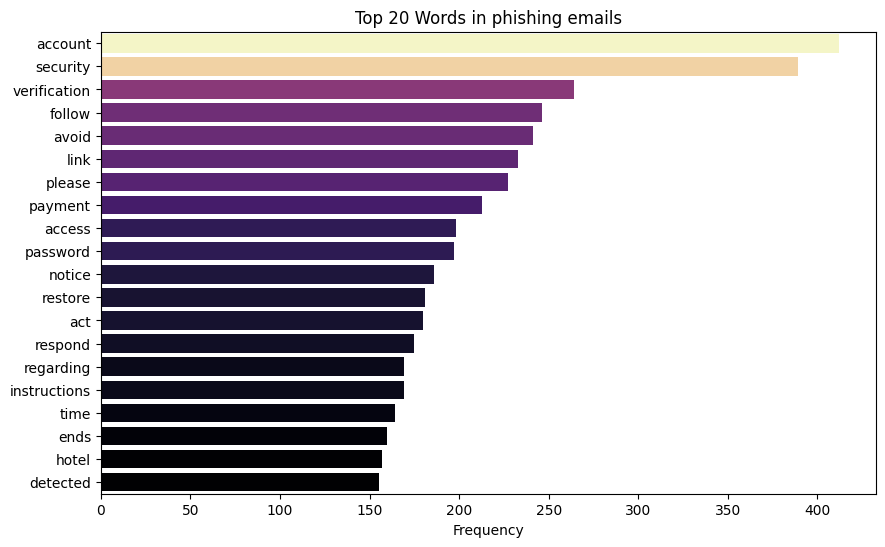

In [ ]:
from collections import Counter
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')

stop_words=set(stopwords.words('english'))

#combine all phishing emails:joins all texts into one string-> converts to lowercase-.splits into words
phishing_words=''.join(df[df['label']==1]['text_combined']).lower().split() #selects only phishing emails

filtered_words=[word for word in phishing_words if word.isalpha() and word not in stop_words] #alphabetic words (removes numbers,punctuations...)
word_freq=Counter(filtered_words).most_common(20)

#barplot of top words
words,counts=zip(*word_freq) #unpacks the 20 most common word-count pairs into two separate lists:words and counts
plt.figure(figsize=(10,6))
sns.barplot(x=list(counts),y=list(words),hue=list(counts),palette='magma', legend=False)
plt.title('Top 20 Words in phishing emails')
plt.xlabel('Frequency')
plt.show()


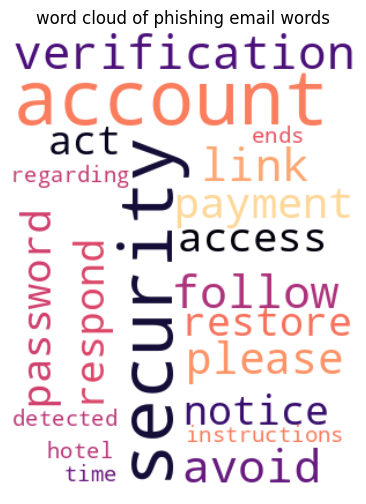

In [ ]:
from wordcloud import WordCloud

# Use the top words and their frequencies directly
# word_freq is available from the previous cell: [('aug', 5156), ...]
word_frequencies = dict(word_freq)

# generate word cloud from frequencies
wordcloud=WordCloud(width=300, height=400, background_color='white', colormap='magma').generate_from_frequencies(word_frequencies)

#display the word cloud
plt.figure(figsize=(12,6))
plt.imshow(wordcloud,interpolation='bilinear')
plt.axis('off')
plt.title('word cloud of phishing email words')
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split

#split out 20% test data
train_val_texts, test_texts, train_val_labels,test_labels=train_test_split(df['text_combined'].tolist(),df['label'].tolist(),test_size=0.2,random_state=42,stratify=df['label'])

#split remainig 80% into 70% train and 10% val
train_texts, val_texts, train_labels, val_labels = train_test_split(
    train_val_texts, train_val_labels,
    test_size=0.125,
    random_state=42, stratify=train_val_labels
)



In [ ]:
val_texts

['dear user, congratulations! you are the selected recipient of a refund. to redeem your payment of ₹80,000, please provide your routing number to process the sum. this deal is available today only.\n\nkeywords: medical treatment jackpot need help\n\ncompliance team,\ncameron garcia',
 'hello, you have a new notification. please click here to view the update. for your convenience, a link and attachment are included. do not reply to this auto-generated message.\n\nkeywords: do not reply, update, click here, spread\n\nsecurity team,\navery nguyen',
 'subject: weekly status report\n\ngood morning, the updated agenda for next week is included below. please check your tasks and add comments.\n\nthanks for reviewing the document.\n\nbest,\njordan patel',
 'subject: documentation review\n\nsharing the revised documentation with examples. the endpoints are described in section two.\n\nfeel free to add notes before we meet.\n\nbest,\nriley garcia',
 'subject: conference registration\n\ni booked

In [ ]:
from transformers import BertTokenizer, BertForSequenceClassification, Trainer, TrainingArguments, DataCollatorWithPadding
import torch
import os
from sklearn.metrics import precision_recall_fscore_support, accuracy_score

#tokenizing
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

#tokenize the datasets
train_encoding = tokenizer(train_texts, truncation=True, padding=True,max_length=512)
val_encoding = tokenizer(val_texts, truncation=True, padding=True,max_length=512)

print(train_encoding['input_ids'][0])
print(train_encoding['attention_mask'][0])


class EmailDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item   # ← IMPORTANT FIX

    def __len__(self):
        return len(self.labels)


train_dataset = EmailDataset(train_encoding, train_labels)
val_dataset = EmailDataset(val_encoding, val_labels)


#loading pretrained BERT for classification
model = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=2)


#define evaluation metrics
def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, preds, average='binary'
    )
    acc = accuracy_score(labels, preds)

    return {
        'accuracy': acc,
        'f1': f1,
        'precision': precision,
        'recall': recall
    }


# tensorboard logging directory
os.environ["TENSORBOARD_LOGGING_DIR"] = "./logs"


#training arguments
training_args = TrainingArguments(
    output_dir='./results',
    eval_strategy='epoch',
    save_strategy='epoch',
    save_total_limit=2,
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=5,
    weight_decay=0.01,
    optim='adamw_torch',
    logging_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='f1',
    greater_is_better=True
)


trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    data_collator=DataCollatorWithPadding(tokenizer=tokenizer),
    compute_metrics=compute_metrics,
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

[101, 3395, 1024, 2836, 12247, 22476, 2075, 1996, 4433, 6378, 1012, 12247, 2011, 5958, 2052, 2022, 12315, 2061, 2057, 2064, 2345, 4697, 2005, 1996, 7396, 1012, 1045, 1005, 2222, 3745, 1996, 14816, 2101, 2651, 1012, 2190, 1010, 3520, 5960, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.102404,0.001294,1.000000,1.000000,1.000000,1.000000
2,0.001062,0.000476,1.000000,1.000000,1.000000,1.000000
3,0.000565,0.000308,1.000000,1.000000,1.000000,1.000000
4,0.000417,0.000246,1.000000,1.000000,1.000000,1.000000
5,0.000360,0.000229,1.000000,1.000000,1.000000,1.000000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=330, training_loss=0.0209616522502267, metrics={'train_runtime': 142.7796, 'train_samples_per_second': 36.77, 'train_steps_per_second': 2.311, 'total_flos': 248208280740000.0, 'train_loss': 0.0209616522502267, 'epoch': 5.0})

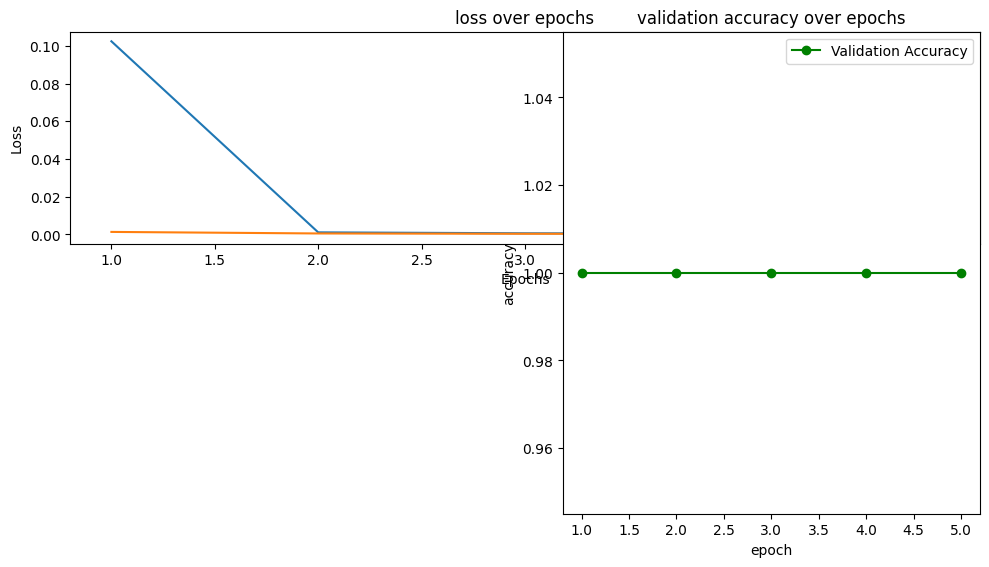

In [ ]:
#extract logs
log_history=trainer.state.log_history

#gather data
train_loss=[entry['loss'] for entry in log_history if 'loss' in entry]
eval_loss=[entry['eval_loss'] for entry in log_history if 'eval_loss' in entry]
eval_acc=[entry['eval_accuracy'] for entry in log_history if 'eval_accuracy' in entry]
epochs=list(range(1,len(eval_loss)+1))

#plot loss
plt.figure(figsize=(10,6))
plt.subplot(2,1,1)
plt.plot(epochs, train_loss, label='Training Loss')
plt.plot(epochs, eval_loss, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('loss over epochs')
plt.legend()

#plot accuracy
plt.subplot(1,2,2)
plt.plot(epochs, eval_acc,marker='o',color='green', label='Validation Accuracy')
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.title('validation accuracy over epochs')
plt.legend()
plt.tight_layout()

plt.tight_layout()
plt.show()

In [ ]:
model_dir="/content/dirve/MyDrive/phishing_email_model01"
model.save_pretrained(model_dir)
tokenizer.save_pretrained(model_dir)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('/content/dirve/MyDrive/phishing_email_model01/tokenizer_config.json',
 '/content/dirve/MyDrive/phishing_email_model01/tokenizer.json')

In [ ]:
from transformers import BertTokenizer, BertForSequenceClassification
# Re-initialize the tokenizer from the original pre-trained model to ensure a clean state
tokenizer=BertTokenizer.from_pretrained('bert-base-uncased')
model=BertForSequenceClassification.from_pretrained(model_dir)
print(f"Tokenizer max length: {tokenizer.model_max_length}")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Tokenizer max length: 512


In [ ]:
test_encoding=tokenizer(test_texts, truncation=True, padding=True, max_length=512)
print(f"Length of first test sequence input_ids after tokenization: {len(test_encoding['input_ids'][0])}")

train_dataset=EmailDataset(train_encoding, train_labels)

Length of first test sequence input_ids after tokenization: 93


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score,classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
test_dataset = EmailDataset(test_encoding, test_labels)


test_results=trainer.predict(test_dataset)
y_pred=test_results.predictions.argmax(axis=1)
y_true=test_labels

# Calculate metrics using sklearn functions after prediction
precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='binary')
acc = accuracy_score(y_true, y_pred)

print("final test evaluation metrices:")
print(f'accuracy:   {acc:.4f}')
print(f'precision:  {precision:.4f}')
print(f'recall:   {recall:.4f}')
print(f'f1:      {f1:.4f}')
print("Classification report")
print(classification_report(y_true,y_pred,target_names=['legitimate','phishing']))

final test evaluation metrices:
accuracy:   1.0000
precision:  1.0000
recall:   1.0000
f1:      1.0000
Classification report
              precision    recall  f1-score   support

  legitimate       1.00      1.00      1.00       117
    phishing       1.00      1.00      1.00       183

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300



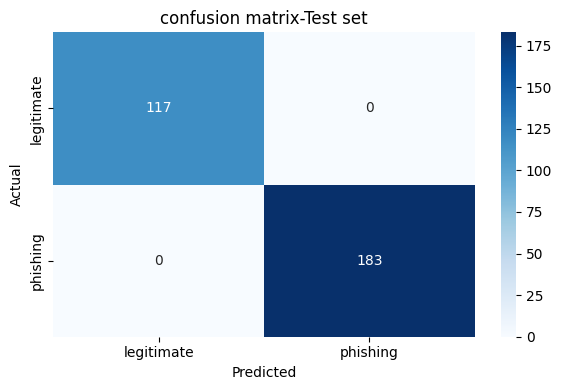

In [ ]:
#plot confusion matrix
cm=confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm,annot=True, fmt='d',cmap='Blues',xticklabels=['legitimate','phishing'],yticklabels=['legitimate','phishing'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('confusion matrix-Test set')
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import classification_report
y_pred=test_results.predictions.argmax(axis=1)
print(classification_report(test_labels,y_pred,target_names=['legitimate','phishing']))

              precision    recall  f1-score   support

  legitimate       1.00      1.00      1.00       117
    phishing       1.00      1.00      1.00       183

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300



In [ ]:
import joblib

joblib.dump(model, "phishing_model01.pkl")

['phishing_model01.pkl']

In [ ]:
joblib.dump(tokenizer, "tokenizer.pkl")

['tokenizer.pkl']

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
print(os.listdir('/content/drive/MyDrive'))

['Colab Notebooks', 'Classroom', 'Google AI Studio', 'Untitled document.gdoc', 'Untitled folder', 'Cognitia AI', 'Neuromail-AI']


In [ ]:
model_dir = "/content/drive/MyDrive/phishing_email_model02"
os.makedirs(model_dir, exist_ok=True)  # creates folder if it doesn't exist

model.save_pretrained(model_dir)
tokenizer.save_pretrained(model_dir)

print("Done! Files saved:")
for f in os.listdir(model_dir):
    size = os.path.getsize(os.path.join(model_dir, f))
    print(f"  {f}  →  {size/1024/1024:.1f} MB")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Done! Files saved:
  config.json  →  0.0 MB
  model.safetensors  →  417.7 MB
  tokenizer_config.json  →  0.0 MB
  tokenizer.json  →  0.7 MB


In [ ]:
save_pretrained()